# Image Histogram Processing
Implementasi:
1. **Histogram Calculation** — Frekuensi setiap level intensitas [0,255]
2. **Histogram Equalization** — Pemerataan kontras via CDF
3. **Histogram Specification** — Matching distribusi ke referensi image

> Mendukung gambar **Grayscale** maupun **RGB**.
>
> Setiap fungsi utama menerima **numpy array** sebagai input dan mengembalikan **numpy array**.

In [1]:
# ============================================================
# Cell 1 — Import Library
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# ============================================================
# Cell 2 — Fungsi Bantu: Load & Show Image
# ============================================================

def load_image(path: str, grayscale: bool = False) -> np.ndarray:
    """
    Load gambar dari path menggunakan Pillow.

    Parameter
    ---------
    path      : str  — path ke file gambar
    grayscale : bool — True  → konversi ke grayscale, shape (H, W)
                       False → load sebagai RGB,       shape (H, W, 3)

    Return
    ------
    np.ndarray, dtype=uint8
    """
    mode = 'L' if grayscale else 'RGB'
    img  = Image.open(path).convert(mode)
    return np.array(img, dtype=np.uint8)


def show_image(img_array: np.ndarray, title: str = 'Image') -> None:
    """
    Tampilkan numpy array sebagai gambar menggunakan imshow().
    Otomatis deteksi mode:
      - shape (H, W)    → grayscale
      - shape (H, W, 3) → RGB
    """
    plt.figure(figsize=(4, 4))
    if img_array.ndim == 2:
        plt.imshow(img_array, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(img_array)          # RGB: imshow langsung terima uint8 [0,255]
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# Cell 3 — Fungsi 1: Histogram Calculation
# ============================================================

def compute_histogram(img_array: np.ndarray) -> np.ndarray:
    """
    Hitung frekuensi setiap level intensitas [0, 255].

    Parameter
    ---------
    img_array : np.ndarray (uint8)
        - Grayscale (H, W)   → output shape (256,)
        - RGB (H, W, 3)      → output shape (3, 256)  [index 0=R, 1=G, 2=B]

    Return
    ------
    hist : np.ndarray, shape (256,) atau (3, 256)
    """
    if img_array.ndim == 2:
        # --- Grayscale ---
        hist = np.zeros(256, dtype=np.int64)
        for val in img_array.flatten():
            hist[val] += 1
        return hist
    else:
        # --- RGB: hitung tiap channel ---
        hist = np.zeros((3, 256), dtype=np.int64)
        for c in range(3):
            for val in img_array[:, :, c].flatten():
                hist[c, val] += 1
        return hist


def plot_histogram(hist: np.ndarray, title: str = 'Histogram') -> None:
    """
    Visualisasi histogram.
    - Grayscale : 1 subplot
    - RGB       : 3 subplot (R, G, B)
    """
    if hist.ndim == 1:
        # --- Grayscale ---
        plt.figure(figsize=(6, 3))
        plt.bar(np.arange(256), hist, width=1, color='steelblue', alpha=0.85)
        plt.title(title)
        plt.xlabel('Intensitas Piksel')
        plt.ylabel('Frekuensi')
        plt.xlim([0, 255])
        plt.tight_layout()
        plt.show()
    else:
        # --- RGB ---
        channel_names  = ['Red', 'Green', 'Blue']
        channel_colors = ['red', 'green', 'blue']
        fig, axes = plt.subplots(1, 3, figsize=(14, 3))
        fig.suptitle(title)
        for i, (ax, name, color) in enumerate(
                zip(axes, channel_names, channel_colors)):
            ax.bar(np.arange(256), hist[i], width=1, color=color, alpha=0.7)
            ax.set_title(f'Channel {name}')
            ax.set_xlabel('Intensitas')
            ax.set_ylabel('Frekuensi')
            ax.set_xlim([0, 255])
        plt.tight_layout()
        plt.show()

In [11]:
# ============================================================
# Cell 4 — Fungsi 2: Histogram Equalization
# ============================================================

def _equalize_channel(channel: np.ndarray) -> np.ndarray:
    """
    Ekualisasi histogram satu channel 2D (H, W) menggunakan CDF.
    Helper internal — dipanggil oleh histogram_equalization().

    Rumus:
        T(r) = round( (CDF(r) - CDF_min) / (N - CDF_min) * 255 )
    """
    hist    = np.zeros(256, dtype=np.int64)
    for val in channel.flatten():
        hist[val] += 1

    cdf     = np.cumsum(hist)
    cdf_min = cdf[cdf > 0][0]        # nilai CDF pertama yang bukan 0
    N       = channel.size

    lut = np.round(
        (cdf - cdf_min) / (N - cdf_min) * 255
    )
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[channel]


def histogram_equalization(img_array: np.ndarray) -> np.ndarray:
    """
    Global histogram equalization menggunakan CDF.

    Parameter
    ---------
    img_array : np.ndarray (uint8)
        - Grayscale (H, W)   → proses langsung
        - RGB (H, W, 3)      → proses tiap channel R, G, B secara independen

    Return
    ------
    np.ndarray (uint8), shape sama dengan input.
    Semua nilai piksel di-round ke integer terdekat dalam [0, 255].
    """
    if img_array.ndim == 2:
        # --- Grayscale ---
        return _equalize_channel(img_array)
    else:
        # --- RGB: proses tiap channel lalu gabung kembali ---
        eq_channels = [
            _equalize_channel(img_array[:, :, c]) for c in range(3)
        ]
        return np.stack(eq_channels, axis=2)

In [12]:
# ============================================================
# Cell 5 — Fungsi 3: Histogram Specification (Matching)
# ============================================================

def _match_channel(src: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """
    Histogram matching untuk satu channel 2D (H, W).
    Helper internal — dipanggil oleh histogram_specification().

    Algoritma:
      1. Hitung CDF_src dan CDF_ref, normalisasi ke [0, 1].
      2. Untuk tiap level r, cari z sehingga |CDF_ref(z) - CDF_src(r)| minimum.
      3. Bangun LUT r → z dan petakan piksel.
    """
    def normalized_cdf(channel: np.ndarray) -> np.ndarray:
        hist    = np.zeros(256, dtype=np.int64)
        for val in channel.flatten():
            hist[val] += 1
        cdf     = np.cumsum(hist).astype(np.float64)
        cdf_min = cdf[cdf > 0][0]
        cdf     = (cdf - cdf_min) / (channel.size - cdf_min)
        return np.clip(cdf, 0, 1)

    cdf_src = normalized_cdf(src)
    cdf_ref = normalized_cdf(ref)

    lut = np.zeros(256, dtype=np.uint8)
    for r in range(256):
        lut[r] = np.argmin(np.abs(cdf_ref - cdf_src[r]))

    return lut[src]


def histogram_specification(img_array: np.ndarray,
                             ref_array: np.ndarray) -> np.ndarray:
    """
    Transformasi distribusi intensitas img_array agar mendekati
    distribusi ref_array (histogram matching).

    Aturan tipe input:
      - Grayscale ↔ Grayscale : matching langsung
      - RGB       ↔ RGB       : matching per channel (R↔R, G↔G, B↔B)
      - Tipe berbeda          : raise ValueError

    Parameter
    ---------
    img_array : np.ndarray (uint8) — input image
    ref_array : np.ndarray (uint8) — reference image

    Return
    ------
    np.ndarray (uint8), shape sama dengan img_array.
    Semua nilai piksel di-round ke integer terdekat dalam [0, 255].
    """
    if img_array.ndim != ref_array.ndim:
        src_mode = 'Grayscale' if img_array.ndim == 2 else 'RGB'
        ref_mode = 'Grayscale' if ref_array.ndim == 2 else 'RGB'
        raise ValueError(
            f'Tipe gambar tidak cocok: input={src_mode}, reference={ref_mode}. '
            f'Pastikan keduanya sama-sama Grayscale atau RGB.'
        )

    if img_array.ndim == 2:
        # --- Grayscale ---
        return _match_channel(img_array, ref_array)
    else:
        # --- RGB: matching tiap channel secara independen ---
        matched_channels = [
            _match_channel(img_array[:, :, c], ref_array[:, :, c])
            for c in range(3)
        ]
        return np.stack(matched_channels, axis=2)

=== TEST: Histogram Calculation (RGB) ===
  Shape  : (911, 1280, 3)
  Min    : 0  |  Max: 255


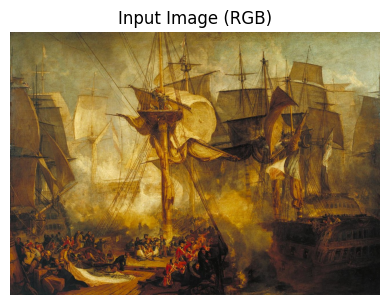

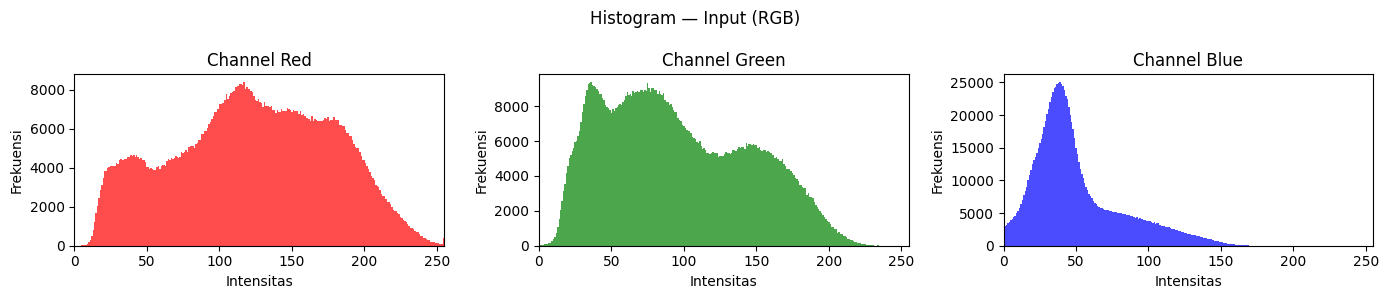

=== TEST: Histogram Calculation (Grayscale) ===
  Shape  : (911, 1280)
  Min    : 0  |  Max: 246


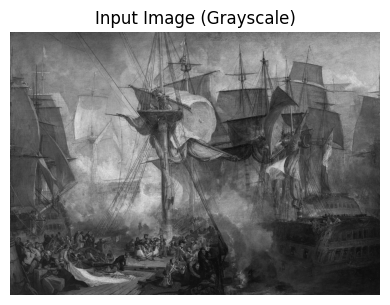

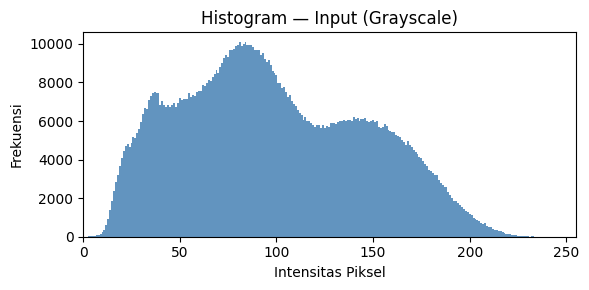

In [15]:
# ============================================================
# Cell 6 — Main: Test Histogram Calculation
# ============================================================

def main_histogram_calculation(image_path: str,
                                grayscale: bool = False) -> None:
    mode_label = 'Grayscale' if grayscale else 'RGB'
    print(f'=== TEST: Histogram Calculation ({mode_label}) ===')

    img  = load_image(image_path, grayscale=grayscale)
    hist = compute_histogram(img)

    print(f'  Shape  : {img.shape}')
    print(f'  Min    : {img.min()}  |  Max: {img.max()}')

    show_image(img, title=f'Input Image ({mode_label})')
    plot_histogram(hist, title=f'Histogram — Input ({mode_label})')


# ── Ganti path di bawah dengan path gambar kamu ──
INPUT_PATH = 'battle_of_trafalgar.jpg'

main_histogram_calculation(INPUT_PATH, grayscale=False)   # RGB
main_histogram_calculation(INPUT_PATH, grayscale=True)    # Grayscale

=== TEST: Histogram Equalization (RGB) ===


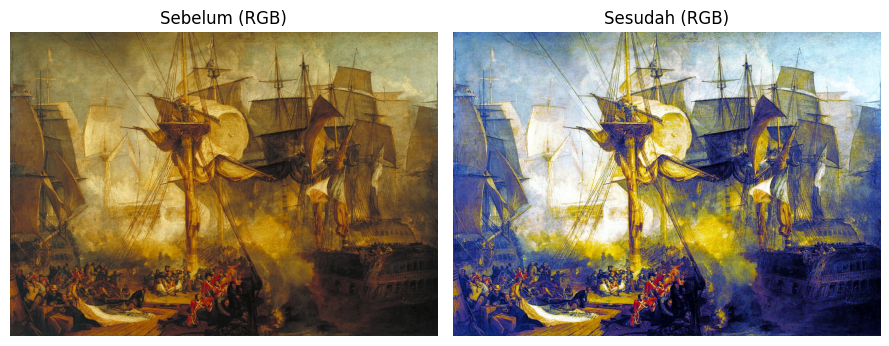

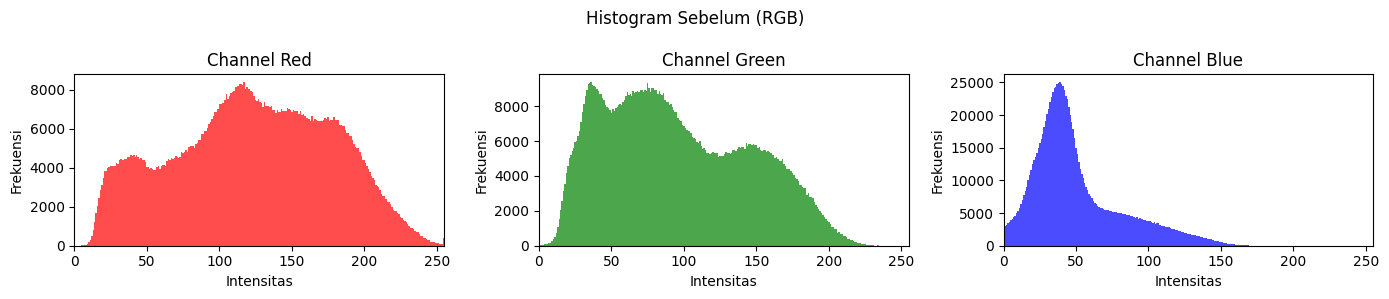

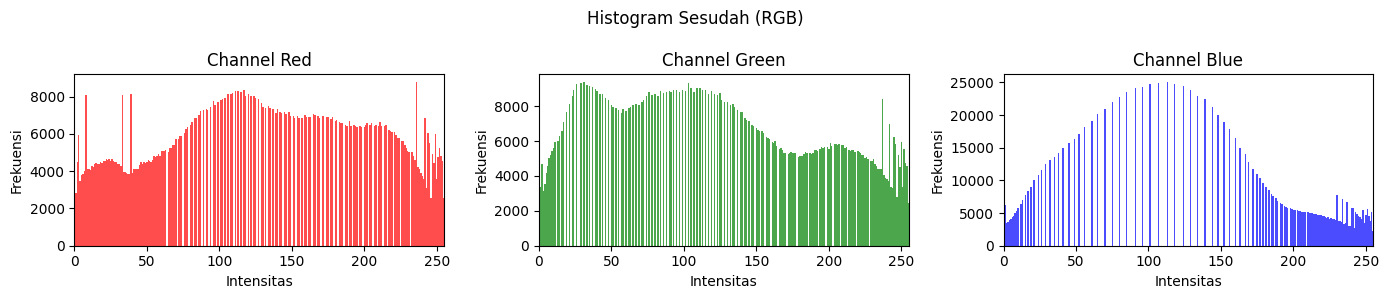

  Min: 0 → 0  |  Max: 255 → 255
=== TEST: Histogram Equalization (Grayscale) ===


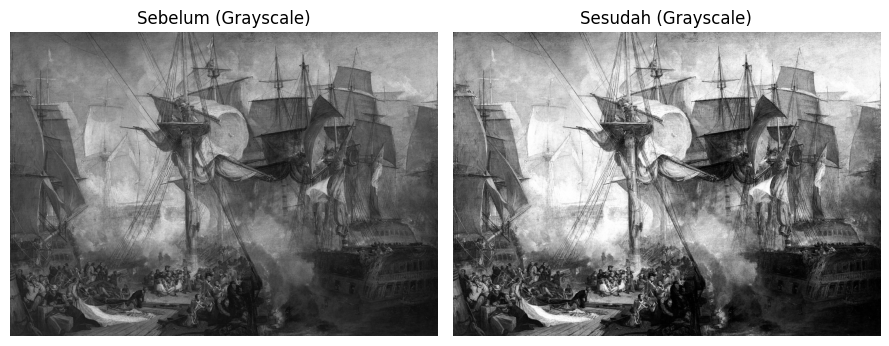

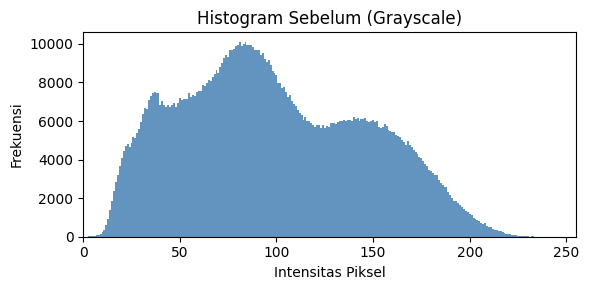

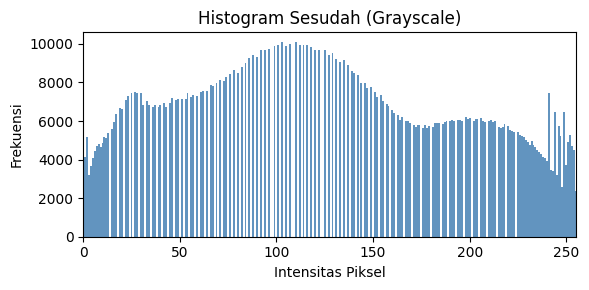

  Min: 0 → 0  |  Max: 246 → 255


In [16]:
# ============================================================
# Cell 7 — Main: Test Histogram Equalization
# ============================================================

def main_histogram_equalization(image_path: str,
                                 grayscale: bool = False) -> None:
    mode_label = 'Grayscale' if grayscale else 'RGB'
    print(f'=== TEST: Histogram Equalization ({mode_label}) ===')

    img    = load_image(image_path, grayscale=grayscale)
    eq_img = histogram_equalization(img)

    hist_before = compute_histogram(img)
    hist_after  = compute_histogram(eq_img)

    # --- Gambar berdampingan ---
    cmap = 'gray' if grayscale else None
    vmin, vmax = (0, 255) if grayscale else (None, None)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img,    cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Sebelum ({mode_label})')
    axes[0].axis('off')
    axes[1].imshow(eq_img, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Sesudah ({mode_label})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # --- Histogram sebelum & sesudah ---
    plot_histogram(hist_before, title=f'Histogram Sebelum ({mode_label})')
    plot_histogram(hist_after,  title=f'Histogram Sesudah ({mode_label})')

    print(f'  Min: {img.min()} → {eq_img.min()}  |  Max: {img.max()} → {eq_img.max()}')


main_histogram_equalization(INPUT_PATH, grayscale=False)   # RGB
main_histogram_equalization(INPUT_PATH, grayscale=True)    # Grayscale

=== TEST: Histogram Specification (RGB) ===


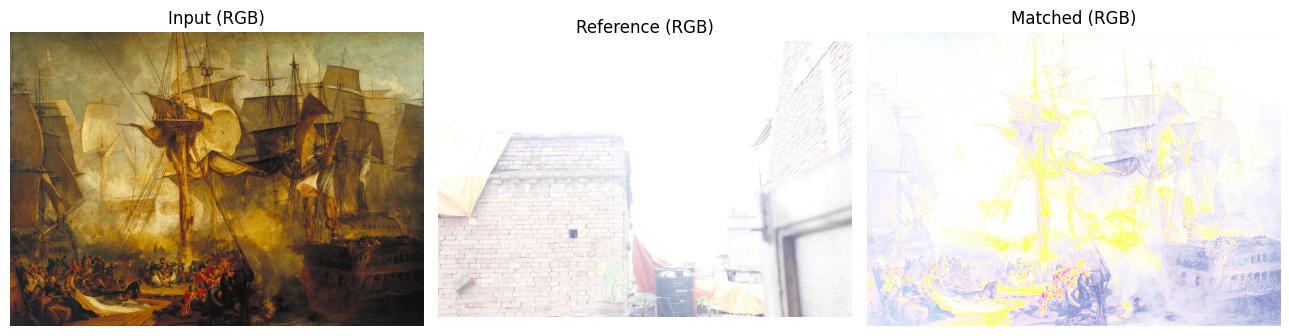

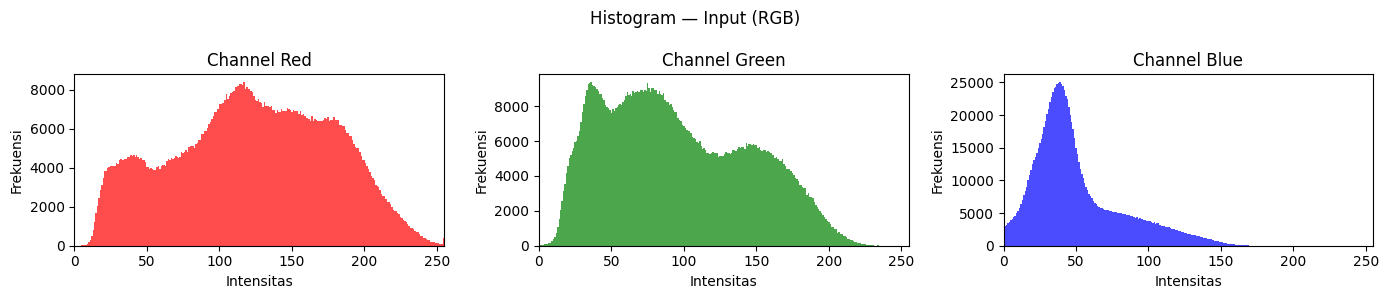

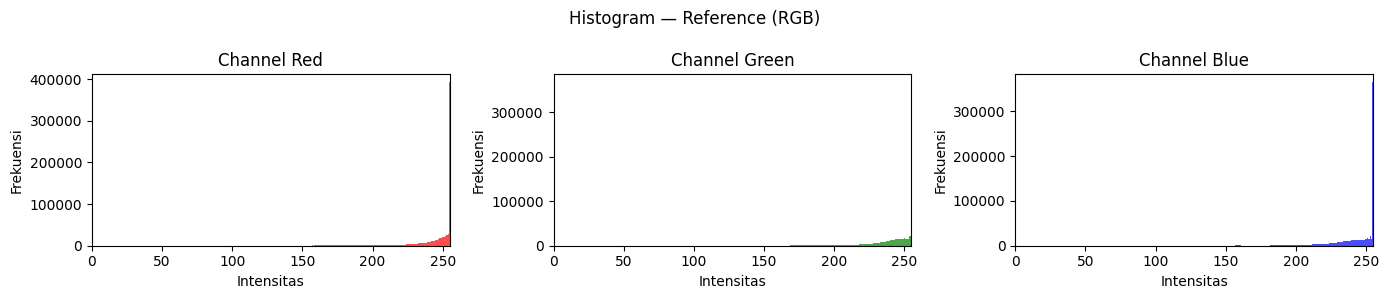

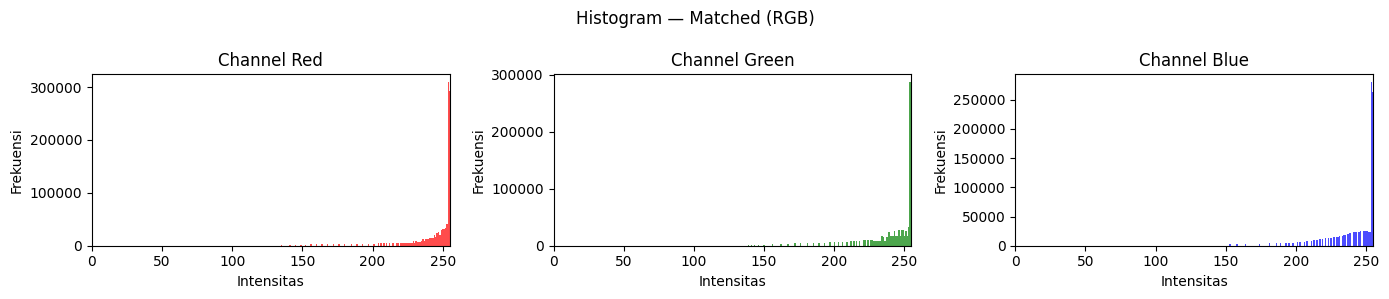

  Input   — min:   0  max: 255
  Ref     — min: 102  max: 255
  Matched — min:   0  max: 255
=== TEST: Histogram Specification (Grayscale) ===


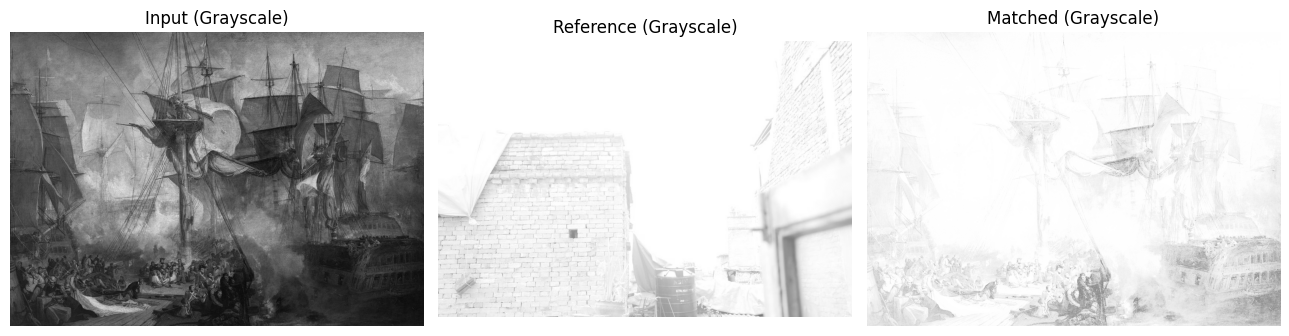

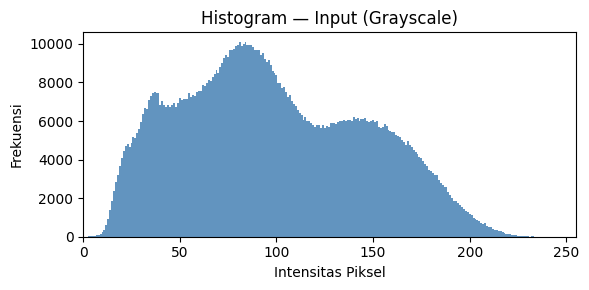

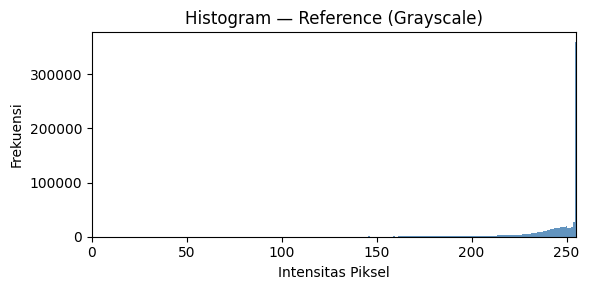

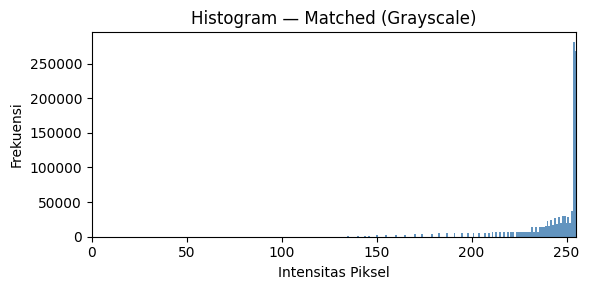

  Input   — min:   0  max: 246
  Ref     — min: 108  max: 255
  Matched — min:   0  max: 255


In [8]:
# ============================================================
# Cell 8 — Main: Test Histogram Specification
# ============================================================

def main_histogram_specification(image_path: str,
                                  reference_path: str,
                                  grayscale: bool = False) -> None:
    mode_label = 'Grayscale' if grayscale else 'RGB'
    print(f'=== TEST: Histogram Specification ({mode_label}) ===')

    img     = load_image(image_path,     grayscale=grayscale)
    ref     = load_image(reference_path, grayscale=grayscale)
    matched = histogram_specification(img, ref)

    hist_input   = compute_histogram(img)
    hist_ref     = compute_histogram(ref)
    hist_matched = compute_histogram(matched)

    # --- Ketiga gambar ---
    cmap = 'gray' if grayscale else None
    vmin, vmax = (0, 255) if grayscale else (None, None)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, im, t in zip(axes,
                         [img, ref, matched],
                         ['Input', 'Reference', 'Matched']):
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'{t} ({mode_label})')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # --- Ketiga histogram ---
    plot_histogram(hist_input,   title=f'Histogram — Input ({mode_label})')
    plot_histogram(hist_ref,     title=f'Histogram — Reference ({mode_label})')
    plot_histogram(hist_matched, title=f'Histogram — Matched ({mode_label})')

    print(f'  Input   — min: {img.min():3d}  max: {img.max():3d}')
    print(f'  Ref     — min: {ref.min():3d}  max: {ref.max():3d}')
    print(f'  Matched — min: {matched.min():3d}  max: {matched.max():3d}')


# ── Ganti path di bawah dengan path reference image kamu ──
REFERENCE_PATH = 'overexposed.jpg'

main_histogram_specification(INPUT_PATH, REFERENCE_PATH, grayscale=False)  # RGB
main_histogram_specification(INPUT_PATH, REFERENCE_PATH, grayscale=True)   # Grayscale